In [2]:
# import statement and helper functions
import rebound
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from scipy import signal

m_sat = 2.85837e-4
m_jup = 9.945786e-4
m_c = 1

def ft(times, x):
    fs = 1/((times[1] - times[0])/(2*np.pi))
    f, pxx = signal.periodogram(x,fs=fs,window='hann',scaling='density')
    return f,pxx

def pomega_ft(times,pomega,ecc):
    k = ecc*np.cos(pomega)
    h = ecc*np.sin(pomega)*1j
    z = h + k
    f,pxx = ft(times, z)
    return f,pxx

#from celmech docs
def get_pomega(kap,eta):
    return np.arctan2(-eta,kap)

def get_ecc(kap,eta,L):
    P = (kap**2 + eta**2)/2
    return np.sqrt(1 - (1 - P/L)**2)

In [3]:
sim = rebound.Simulation()
sim.integrator = "whfast"
sim.dt = 1e-1
sim.add(m=1, hash = "Sun")
sim.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
sim.add(m=0,a=8.9,e=0.03,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

sim.move_to_com()

times = np.linspace(0,1e7,int(1e5))*2*np.pi
e_sat_test_particle = np.zeros(len(times))
sat_p = np.zeros(len(times))
j_p = np.zeros(len(times))
H_energy = np.zeros(len(times))
a_sat_test_particle = np.zeros(len(times))

print(1e7*2*np.pi/sim.particles[2].P)

#sim.init_megno()

e_i = sim.energy()
print('Initial Energy: ' + str(e_i))
print('Initital Angular Momentum: ' + str(sim.angular_momentum()))

for i in tqdm(range(len(times))):
    sim.integrate(times[i])
    e_sat_test_particle[i] = sim.particles[2].e
    a_sat_test_particle[i] = sim.particles[2].a
    sat_p[i] = sim.particles[2].P
    j_p[i] = sim.particles[1].P
    H_energy[i] = sim.energy()
    
e_f = sim.energy()
print('Final Energy: ' + str(e_f))
e_per = (np.abs(e_i - e_f)/np.abs(e_i))*100
print(f'Energy Percent Change: {e_per} %')
print('Final Angular Momentum: ' + str(sim.angular_momentum()))

final_p_ratio = sat_p/j_p

376817.3167445681
Initial Energy: -8.880166071428572e-05
Initital Angular Momentum: <rebound.vectors.Vec3d object at 0x72308f29ef90, [0.0, 0.0, 0.002348194793041187]>


100%|██████████████████████████████████████████████████████████████████████████| 100000/100000 [05:03<00:00, 329.96it/s]

Final Energy: -8.880166071436119e-05
Energy Percent Change: 8.497641890705273e-11 %
Final Angular Momentum: <rebound.vectors.Vec3d object at 0x72308f2e7890, [0.0, 0.0, 0.002348194793040073]>


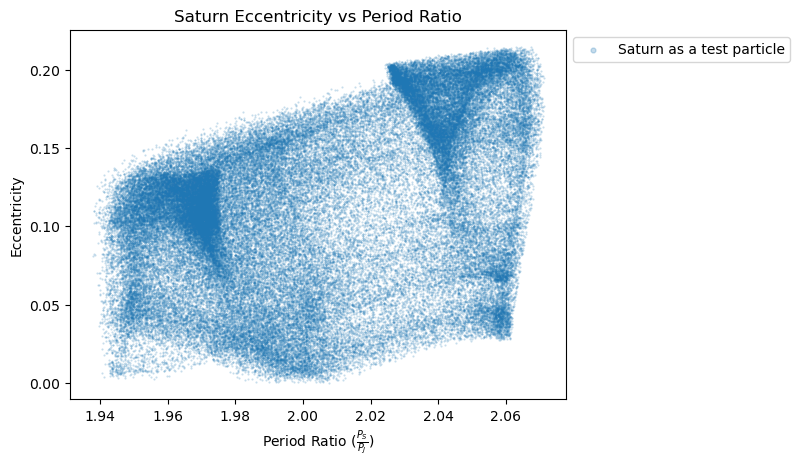

In [4]:
plt.scatter(final_p_ratio, e_sat_test_particle, label="Saturn as a test particle", s=0.25, alpha = 0.25)
plt.xlabel(r'Period Ratio ($\frac{P_S}{P_J}$)')
plt.ylabel('Eccentricity')
plt.legend(bbox_to_anchor=(1, 1), loc='upper left',markerscale=7.0)
plt.title('Saturn Eccentricity vs Period Ratio')
plt.show()

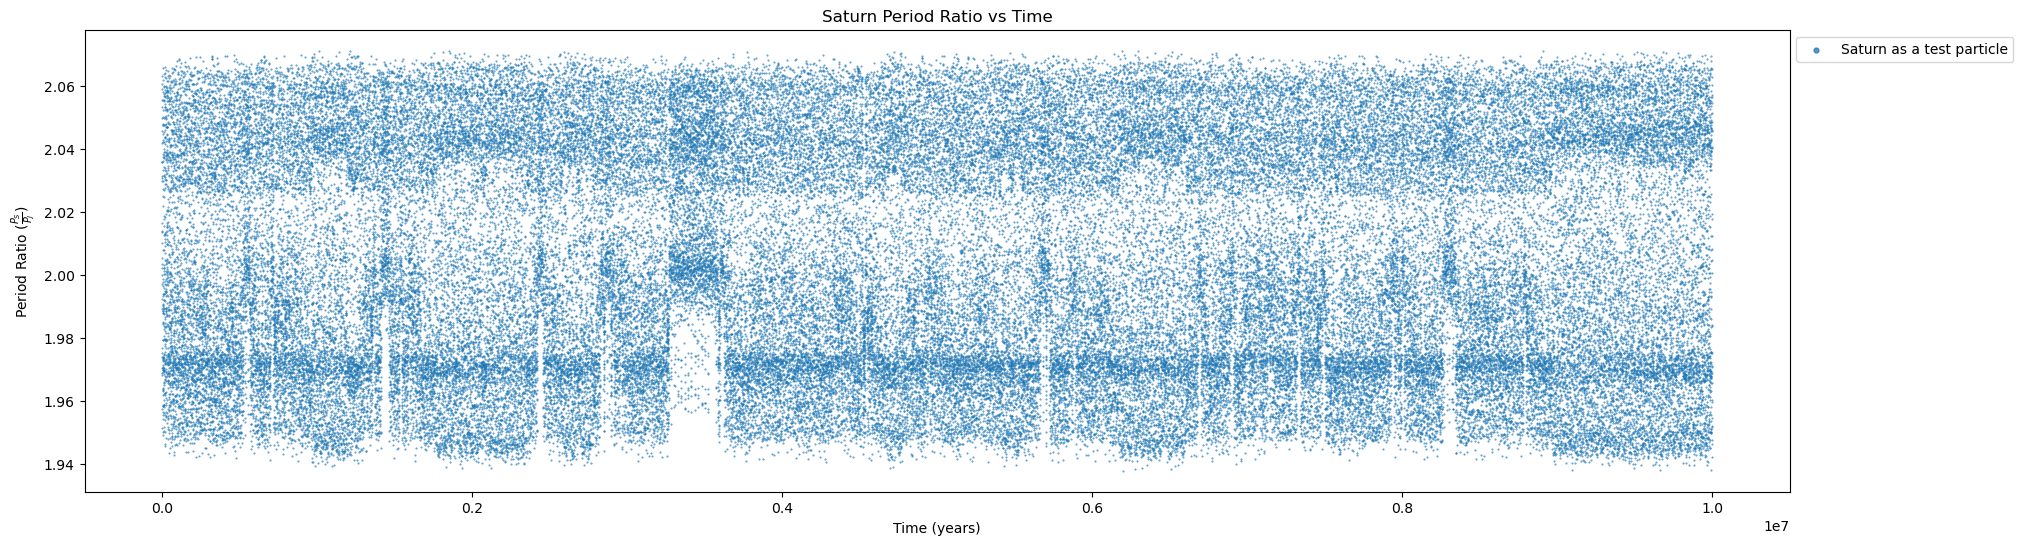

In [5]:

plt.figure(figsize=(22, 6)) 
plt.scatter(times/(2*np.pi), final_p_ratio, label="Saturn as a test particle", s=0.25, alpha = 0.75)
plt.xlabel('Time (years)')
plt.ylabel(r'Period Ratio ($\frac{P_S}{P_J}$)')
plt.legend(bbox_to_anchor=(1, 1), loc='upper left',markerscale=7.0)
plt.title('Saturn Period Ratio vs Time')
plt.show()